## Imports, Style, and Reproducibility
- Load trained models
- Define spatial grid
- Set plotting utilities

In [1]:
# %load_ext is safe to repeatedly run in a Jupyter notebook; it will just ignore duplicates.
#%reload_ext autoreload
#%autoreload 2
%matplotlib inline

In [2]:
import torch
import matplotlib.pyplot as plt
#import seaborn as sns

# Figures
#sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "lines.linewidth": 2,
})

# Repo imports (assumes repo root is on PYTHONPATH)
from model import InverseSchrodingerModel
from utils import make_grid, set_global_seed
from physics import tise_loss, potential_smoothness_loss
from inverse import data_mismatch_loss
from pod import pod_decomposition

set_global_seed(27)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Part 1 - Training the Model

### 1️⃣ Synthetic problem definition
Create a 1-D harmonic oscillator test case for the inverse Schrödinger model to try and recover.

In [3]:
# Spatial grid
n_points = 256        # Number of collocation points
x = make_grid(-5.0, 5.0, n_points)       # (n_points, 1) -> n_points collocation points
dx = float(x[1] - x[0])                  # grid spacing (scalar)

# Choose a known analytic potential (e.g., harmonic oscillator)
V_true = 0.5 * x.squeeze()**2       # shape (N,)

# Analytic eigenfunctions (Hermite-Gaussians) for the chosen analytic potential (harmonic oscillator)
def hermite_gauss(n: int, x_vals: torch.Tensor) -> torch.Tensor:
    """Return the nth normalized harmonic oscillator eigenfunction."""
    from math import factorial, sqrt, pi
    import scipy.special as sp
    norm = 1.0 / sqrt(2.0**n * factorial(n)) * (pi**-0.25)
    # sp.hermite returns a callable polynomial; evaluate on x_vals
    return norm * sp.hermite(n)(x_vals) * torch.exp(-0.5 * x_vals**2)

n_states = 3     # number of eigenstates to evaluate/learn
psi_true = [hermite_gauss(n, x.squeeze()) for n in range(n_states)]
E_true = torch.tensor([0.5, 1.5, 2.5])  # exact energies (hbar = omega = 1)

# Synthetic observed data with some noise so the model has something to fit
rho_obs = [psi**2 + 0.02 * torch.randn_like(psi) for psi in psi_true]
E_obs = E_true + 0.05 * torch.randn_like(E_true)

### 2️⃣ Training loop
Train the inverse Schrödinger model on synthetic observed data (defined above). 

In [4]:
# ============================================================================
# 🎛️ CONFIGURATION PARAMETERS
# ============================================================================
# Training hyperparameters
lr              = 5e-3      # Learning rate
epochs          = 6_000     # Number of training epochs
log_every       = 800       # Print loss every N epochs

# Build the network
model = InverseSchrodingerModel(
    n_states=n_states,
    hidden_dims=[64, 64],
    device=device,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

lambdas = {"data": 1.0, "physics": 1.0, "smooth": 1e-2}

# ----------------------------------------------------------------------
# Training loop (with component logging)
# ----------------------------------------------------------------------

loss_history = []
physics_history = []    # TISE  residual
data_history = []       # data-fit
smooth_history = []     # potential smoothness

for epoch in range(1, epochs + 1):
    # Run a single optimization step and retrieve the three components
    optimizer.zero_grad()

    # ------------------- Physics‑informed loss -------------------
    loss_physics = tise_loss(
        model.psi_theta(x),     # list[psi_n(theta, x)]
        model.V_theta(x),       # V(theta, x)
        model.E_theta(),        # E(theta)
        dx,
    )

    # ------------------- Physics‑informed loss -------------------
    loss_physics = tise_loss(
        model.psi_theta(x),     # list[psi_n(theta, x)]
        model.V_theta(x),       # V(theta, x)
        model.E_theta(),        # E(theta)
        dx,
    )

    # ------------------- Smoothness regularizer -------------------
    loss_smooth = potential_smoothness_loss(model.V_theta(x), dx)

    # ------------------- Data‑fit loss ----------------------------
    loss_data = data_mismatch_loss(
        model.psi_theta(x),     # learned psi_n(theta, x)
        model.E_theta(),        # learned energies
        rho_obs,                # observed probability densities
        E_obs,                  # observed energies
    )

    # ------------------- Weighted sum ----------------------------
    total_loss = (
        lambdas["data"] * loss_data
        + lambdas["physics"] * loss_physics
        + lambdas["smooth"] * loss_smooth
    )

    total_loss.backward()
    optimizer.step()

    # ------------------- Store scalars ---------------------------
    loss_history.append(total_loss.item())
    physics_history.append(loss_physics.item())
    data_history.append(loss_data.item())
    smooth_history.append(loss_smooth.item())

    # ----- logging -----------------------------------------------
    if epoch % log_every == 0 or epoch == 1:
        print(f" epoch {epoch:4d} | total={total_loss.item():.6e} "
              f" | phys={loss_physics.item():.6e} "
              f" | data={loss_data.item():.6e} "
              f" | smooth={loss_smooth.item():.6e}")

# ----------------------------------------------------------------------
# Post-training sanity check
# ----------------------------------------------------------------------
initial_loss = loss_history[0]
final_loss = loss_history[-1]
print("\n ✔️ Training complete!")
print(f"Initial loss: {initial_loss:.6e}")
print(f"Final loss: {final_loss:.6e}")

 epoch    1 | total=7.441536e+00  | phys=5.803766e-02  | data=7.380219e+00  | smooth=3.278965e-01
 epoch  800 | total=3.270497e-01  | phys=9.351968e-03  | data=3.176518e-01  | smooth=4.592888e-03
 epoch 1600 | total=3.346438e-02  | phys=5.430609e-07  | data=3.341792e-02  | smooth=4.591917e-03
 epoch 2400 | total=3.182578e-02  | phys=2.835344e-05  | data=3.175153e-02  | smooth=4.589688e-03
 epoch 3200 | total=3.201478e-02  | phys=2.245059e-04  | data=3.174441e-02  | smooth=4.585797e-03
 epoch 4000 | total=3.179909e-02  | phys=1.906175e-06  | data=3.175139e-02  | smooth=4.578857e-03
 epoch 4800 | total=3.179783e-02  | phys=3.432401e-07  | data=3.175140e-02  | smooth=4.607882e-03
 epoch 5600 | total=3.179958e-02  | phys=1.162028e-06  | data=3.175139e-02  | smooth=4.702811e-03

 ✔️ Training complete!
Initial loss: 7.441536e+00
Final loss: 3.213647e-02


## Part 2 - Figures

## 1️⃣ Figure 1: Training curve
### 📈 Plot
- Figure 1a: Total loss vs. epoch
- Optional: physics vs. data vs. smoothness (stacked or separate)

> 🏡 *"The inverse problem stabilizes under competing physical and data-driven objectives."*


C:\Users\sofia\AppData\Local\Temp\ipykernel_31464\3904028966.py:66: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=200, bbox_inches="tight")


📈 Composite figure saved to ../artifacts/demo_visuals/training_curves.png


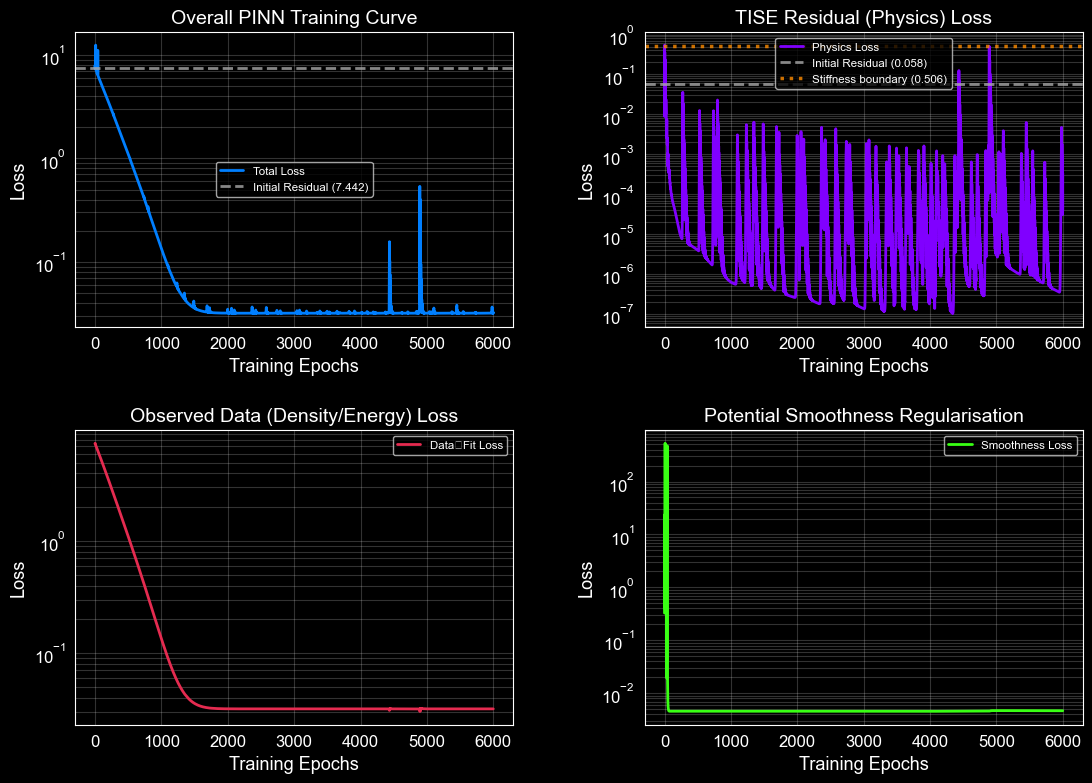

In [20]:
# ----------------------------------------------------------------------
# Composite figure (2 × 2 grid)
# ----------------------------------------------------------------------
fig = plt.figure(figsize=(13, 9))
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.30)

# ── Top‑left: TOTAL LOSS (spans both columns for emphasis) ───────────────
ax_total = fig.add_subplot(gs[0, 0])
ax_total.plot(loss_history, linewidth=2, color="#007FFF", label="Total Loss")
ax_total.axhline(
    y=initial_loss,
    color="#A9A9A9",
    ls="--",
    lw=2,
    alpha=0.8,
    label=f"Initial Residual ({initial_loss:.3f})",
)
ax_total.set_yscale("log")
ax_total.set_xlabel("Training Epochs")
ax_total.set_ylabel("Loss")
ax_total.set_title("Overall PINN Training Curve")
ax_total.grid(True, which="both", alpha=0.2)
ax_total.legend(frameon=True, fontsize="x-small", loc="best")

# ── Top‑right: PHYSICS (TISE) LOSS ───────────────────────────────────────
initial_physics_val = physics_history[0]
peak_residual = max(physics_history[1000:])

ax_phys = fig.add_subplot(gs[0, 1])
ax_phys.plot(physics_history, color="#8000FF", linewidth=2, label="Physics Loss")
ax_phys.axhline(y=initial_physics_val, color="#A9A9A9", ls="--", lw=2, alpha=0.8,
                label=f"Initial Residual ({initial_physics_val:.3f})")
ax_phys.axhline(y=peak_residual, color="#FF8C00", ls=":", lw=2.5, alpha=0.8,
                label=f"Stiffness boundary ({peak_residual:.3f})")
ax_phys.set_yscale("log")
ax_phys.set_xlabel("Training Epochs")
ax_phys.set_ylabel("Loss")
ax_phys.set_title("TISE Residual (Physics) Loss")
ax_phys.grid(True, which="both", alpha=0.2)
ax_phys.legend(frameon=True, fontsize="x-small", loc="best")

# ── Bottom‑left: DATA‑FIT LOSS ───────────────────────────────────────────
ax_data = fig.add_subplot(gs[1, 0])
ax_data.plot(data_history, color="#E52B50", linewidth=2, label="Data‑Fit Loss")
ax_data.set_yscale("log")
ax_data.set_xlabel("Training Epochs")
ax_data.set_ylabel("Loss")
ax_data.set_title("Observed Data (Density/Energy) Loss")
ax_data.grid(True, which="both", alpha=0.2)
ax_data.legend(frameon=True, fontsize="x-small", loc="best")

# ── Bottom‑right: SMOOTHNESS LOSS ───────────────────────────────────────
ax_smooth = fig.add_subplot(gs[1, 1])
ax_smooth.plot(smooth_history, color="#39FF14", linewidth=2, label="Smoothness Loss")
ax_smooth.set_yscale("log")
ax_smooth.set_xlabel("Training Epochs")
ax_smooth.set_ylabel("Loss")
ax_smooth.set_title("Potential Smoothness Regularisation")
ax_smooth.grid(True, which="both", alpha=0.2)
ax_smooth.legend(frameon=True, fontsize="x-small", loc="best")

# ----------------------------------------------------------------------
# Save & display
# ----------------------------------------------------------------------
out_path = "../artifacts/demo_visuals/training_curves.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"📈 Composite figure saved to {out_path}")

plt.show()

## 2️⃣ Figure 2: Learned potential

### 📈 Plot
- $V_\theta(x)$ vs. $x$
- Ground truth $V(x)$

### 💬 Messages
- Smoothness prior effect
- Identifiability limits
- Bias vs. variance tradeoff

### ✖️ Failure modes
- Flattening
- Over-smoothing
- Boundary artifacts

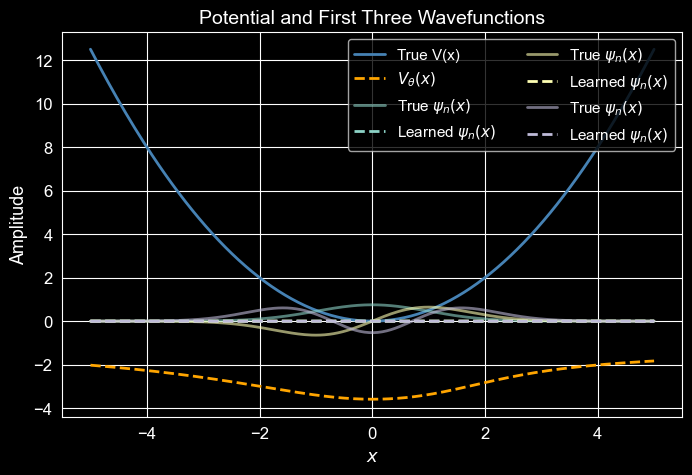

In [7]:
V_learned = model.V_theta(x).detach().squeeze()
psi_learned = [p.detach().squeeze() for p in model.psi_theta(x)]

fig, ax = plt.subplots()
ax.plot(x.squeeze(), V_true, label="True V(x)", color="steelblue", lw=2)
ax.plot(x.squeeze(), V_learned, "--", label=r"$V_\theta(x)$", color="orange")

colors = ["C0", "C1", "C2"]
for n, (psi_t, psi_l) in enumerate(zip(psi_true, psi_learned)):
    ax.plot(
        x.squeeze(),
        psi_t,
        label=rf"True $\psi_n(x)$",
        color=colors[n],
        alpha=0.6,
    )
    ax.plot(
        x.squeeze(),
        psi_l,
        "--",
        label=rf"Learned $\psi_n(x)$",
        color=colors[n],
    )

ax.set_xlabel(rf"$x$")
ax.set_ylabel("Amplitude")
ax.set_title("Potential and First Three Wavefunctions")
ax.legend(loc="upper right", ncol=2)
plt.show()

## 3️⃣ Figure 3: Learned wave function $\psi_n(\theta, x)$
### 📈 Plot
- Learned ${\psi_0}_\theta$, ${\psi_1}_\theta$ and ${\psi_2}_\theta$ (3 subplots)

### 💬 Messages
- Phase ambiguity
- Shape consistency
- Node Structure

> ✨ Do _not_ claim correctness; just structure.

In [8]:
# figure 3

## 4️⃣ Figure 4: Energy spectrum comparison

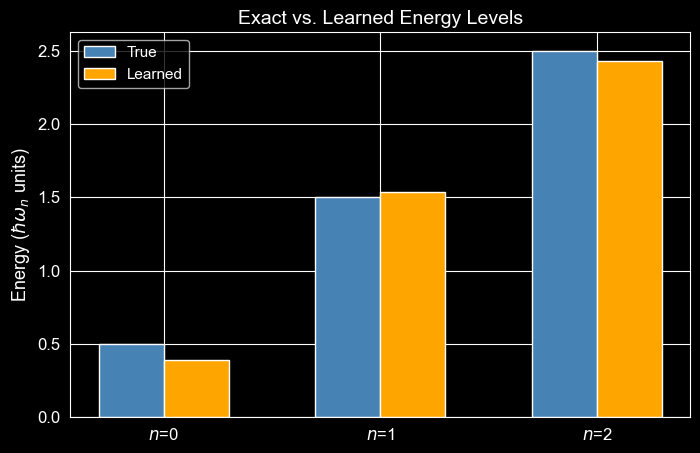

In [9]:
E_learned = model.E_theta().detach()

fig, ax = plt.subplots()
indices = torch.arange(len(E_true)).numpy()

ax.bar(indices - 0.15, E_true.numpy(), width=0.3, label="True", color="steelblue")
ax.bar(indices + 0.15, E_learned.numpy(), width=0.3, label="Learned", color="orange")

ax.set_xticks(indices)
ax.set_xticklabels([rf"$n$={i}" for i in indices])
ax.set_ylabel(rf"Energy ($\hbar \omega_n$ units)")
ax.set_title("Exact vs. Learned Energy Levels")
ax.legend()
plt.show()

## 5️⃣ Figure 5: Probability densities $|\psi_n(\theta, x)|^2$ vs. observations
- Plot
    -  $|\psi_n(x)|^2$
    - Observed $\rho_n(x)$
- Message
    - Data anchoring
    - Indirect supervision
    - Why phase remains unconstrained

In [10]:
# figure 5 code

## 6️⃣ Figure 6: Overlap matrix heatmap (POD diagnostic)
- Plot
    - Heatmap of $\langle \psi_m | \psi_n \rangle$
- Message
    - Near-orthogonality emerges (or not)
    - Coupling through shared $V(x)$
- ✨ This is very important for interpretability.

In [11]:
# Figure 6 code

## 7️⃣ Figure 7: POD singular values
- Plot
    - Singular values $\sigma_k$ vs. $k$ (log scale)
- Message
    - Effective dimensionality
    - Redundant modes
    - Capacity vs. constraint
- Failure mode
    - One dominant singular value -> collapse (❓)

In [12]:
# Figure 7 code

## 8️⃣ Figure 8: POD singular values and dominant modes 

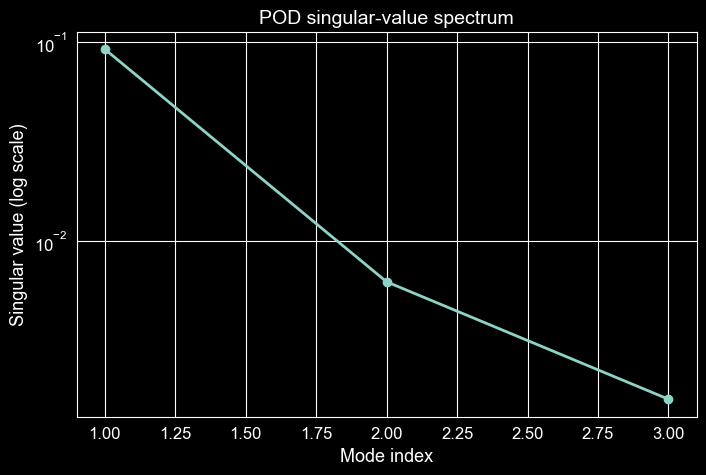

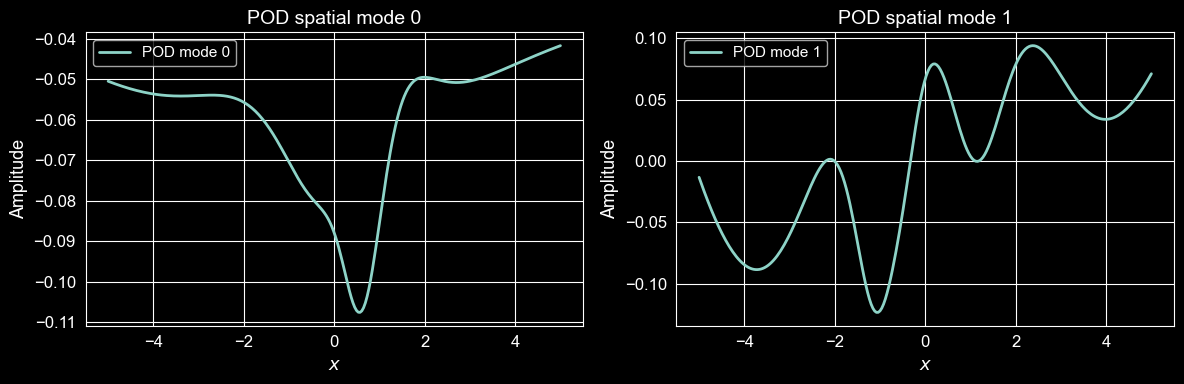

In [13]:
# Stack the learned wavefunctions column-wise to feed POD
psi_matrix = torch.stack(psi_learned, dim=1)    # shape (N, n_states)

U, S, Vh = pod_decomposition(psi_matrix)

# 8a - Singular values (energy content)
fig, ax = plt.subplots()
ax.semilogy(range(1, len(S)+1), S.detach().cpu().numpy(), "o-")
ax.set_xlabel("Mode index")
ax.set_ylabel("Singular value (log scale)")
ax.set_title("POD singular-value spectrum")
plt.show()

# 8b - First two spatial POD modes (they should resemble the true eigenmodes)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for k in range(2):
    axs[k].plot(x.squeeze(), U[:, k].detach(), label=f"POD mode {k}")
    axs[k].set_xlabel(rf"$x$")
    axs[k].set_ylabel("Amplitude")
    axs[k].set_title(f"POD spatial mode {k}")
    axs[k].legend()
plt.tight_layout()
plt.show()

## 9️⃣ Figure 9: POD dominant modes vs. learned wavefunctions (optional if energy ordering is messy)
- Plot
    - Compare POD spatial modes to $\psi_n(\theta, x)$
- Message
    - Learned basis is not equivalent to ground truth physical eigenbasis
    - Still explains data

In [14]:
# Figure 9 code

## 🔟 Figure 10: Loss-weight bifurcation diagram
🥅 Generate a bifurcation diagram that gives us identifiability information.

### 📈 Plot
- $x$-axis: $\frac{\lambda_\text{phys}}{\lambda_\text{data}}$ (log scale)
- $y$-axis (multiple panels):
    - $|| V - V_\text{ref} ||_2$
    - smallest POD singular value
    - max off-diagonal overlap

### 🗝️ Key takeaway
> As physics dominace increases, identifiability goes through sharp transitions. Note that beyond a critical regime (❓ What is this?), the ${\psi_n}_\theta$ collapse into a low-dimensional subspace regardless of whether they satisfy the PDE.

- Makes interpretability axes concrete
- Shows where physics stops helping
- Distinguishes "stable but meaningless" from "informative"

### ✖️ Failure modes
- Flat $V(x)$ and low loss
- POD rank collapse
- Artificial orthogonality